In [1]:
import uproot
import matplotlib.pyplot as plt
import mplhep
import pandas
import numpy as np
import scipy
import vector
import awkward as ak

vector.register_awkward()

In [2]:
keys = [
    "MCParticles.PDG",
    "MCParticles.charge",
    "MCParticles.time",
    "MCParticles.mass",
    "MCParticles.vertex.x",
    "MCParticles.vertex.y",
    "MCParticles.vertex.z",
    "MCParticles.momentum.x",
    "MCParticles.momentum.y",
    "MCParticles.momentum.z",
    "MCParticles.helicity",
]

momentum_keys = {
    "px": "MCParticles.momentum.x",
    "py": "MCParticles.momentum.y",
    "pz": "MCParticles.momentum.z",
    "pt": "sqrt(px**2 + py**2)",
}

vertex_keys = {
    "x": "MCParticles.vertex.x",
    "y": "MCParticles.vertex.y",
    "z": "MCParticles.vertex.z",
    "rho": "sqrt(x**2 + y**2)",
}

In [3]:
with uproot.open("IDEA_sim.root:events") as f:
    tree = f["MCParticles"]

    events = tree.arrays(cut="abs(pdg) == 11", aliases={"pdg": "MCParticles.PDG"})

    vertex = tree.arrays(vertex_keys.keys(), aliases=vertex_keys)
    momentum = tree.arrays(momentum_keys.keys(), aliases=momentum_keys)

In [4]:
leptons = ak.zip({"px": events["MCParticles.momentum.x"], "py": events["MCParticles.momentum.y"], "pz": events["MCParticles.momentum.z"], "mass": events["MCParticles.mass"]}, with_name="Momentum4D")
leptons

<MomentumArray4D [[{px: 4.82, py: 1.12, ...}, ...], ...] type='10 * var * M...'>

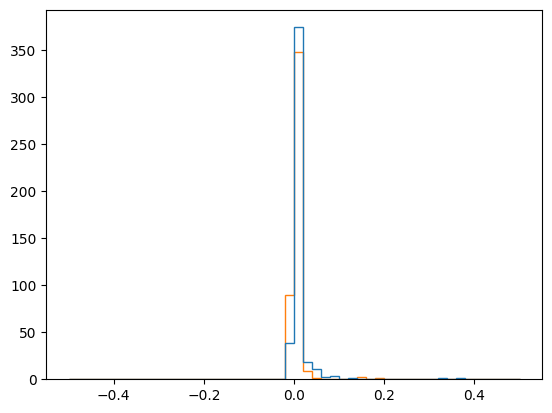

In [5]:
plt.hist([leptons[0].px, leptons[0].py], bins=50, range=(-0.5, 0.5), histtype="step")

plt.show()

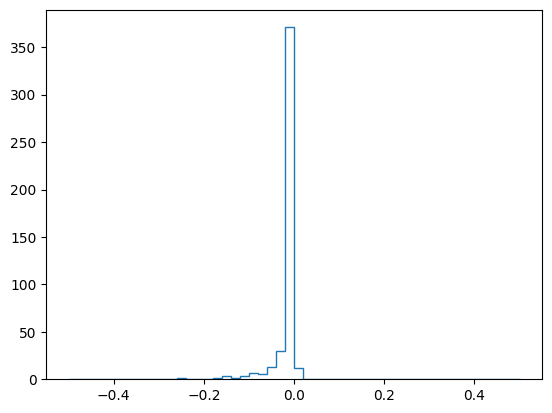

In [6]:
plt.hist(leptons[0].pz, bins=50, range=(-0.5, 0.5), histtype="step")

plt.show()

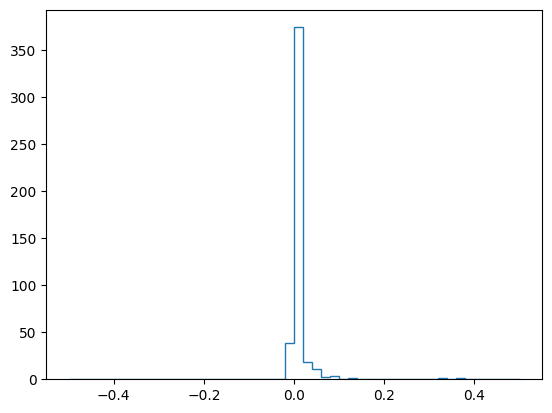

In [7]:
plt.hist(leptons[0].px, bins=50, range=(-0.5, 0.5), histtype="step")

plt.show()

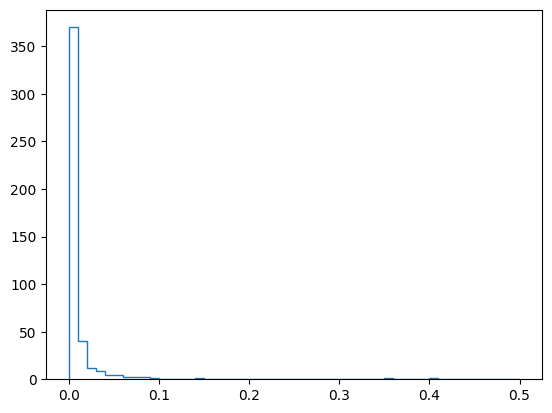

In [8]:
plt.hist(leptons[0].pt, bins=50, range=(0, 0.5), histtype="step")

plt.show()

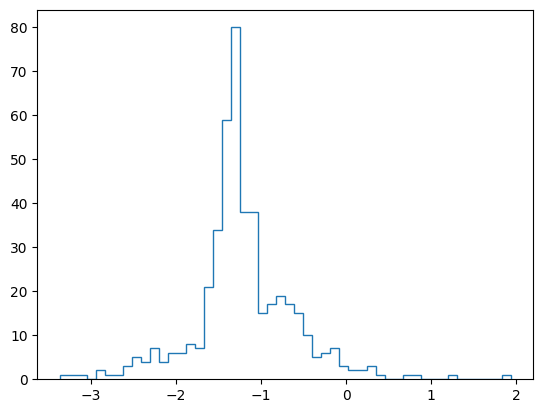

In [9]:
plt.hist(leptons[0].eta, bins=50, histtype="step")

plt.show()

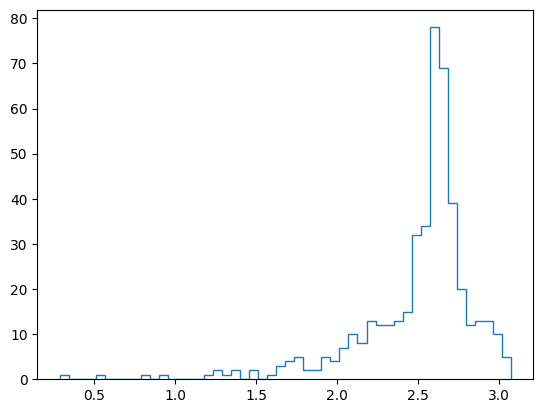

In [10]:
plt.hist(leptons[0].theta, bins=50, histtype="step")

plt.show()

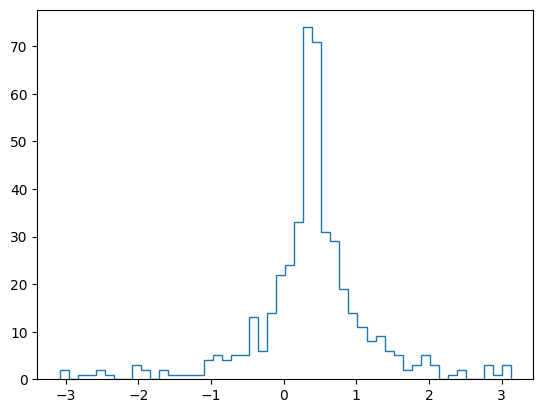

In [11]:
plt.hist(leptons[0].phi, bins=50, histtype="step")

plt.show()

In [12]:
all_x = np.concatenate([event['x'] for event in vertex])
all_y = np.concatenate([event['y'] for event in vertex])
all_z = np.concatenate([event['z'] for event in vertex])
all_rho = np.concatenate([event['rho'] for event in vertex])

In [13]:
all_px = np.concatenate([event['px'] for event in momentum])
all_py = np.concatenate([event['py'] for event in momentum])
all_pz = np.concatenate([event['pz'] for event in momentum])
all_pt = np.concatenate([event['pt'] for event in momentum])

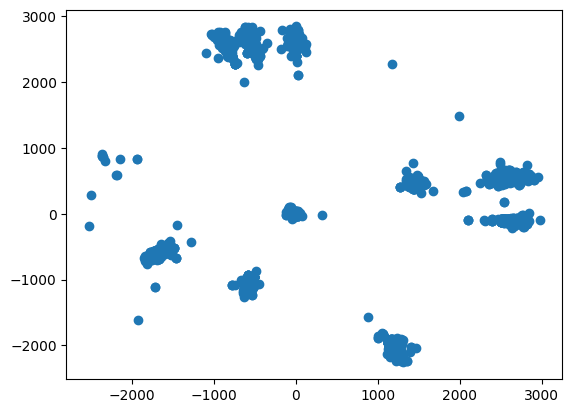

In [14]:
plt.scatter(all_x, all_y)

plt.show()

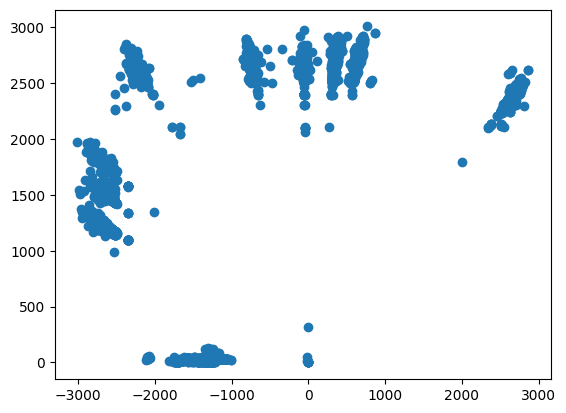

In [15]:
plt.scatter(all_z, all_rho)

plt.show()

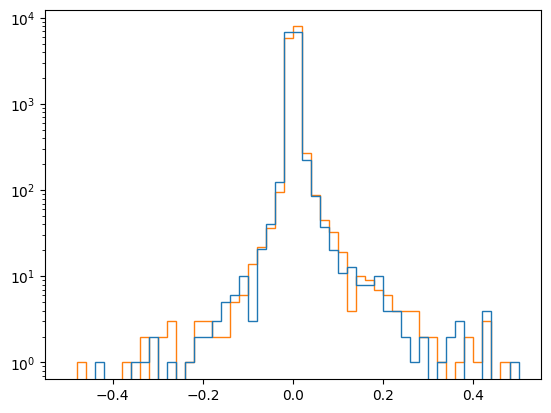

In [16]:
plt.hist([all_px, all_py], bins=50, range=(-0.5, 0.5), histtype="step", log=True)

plt.show()

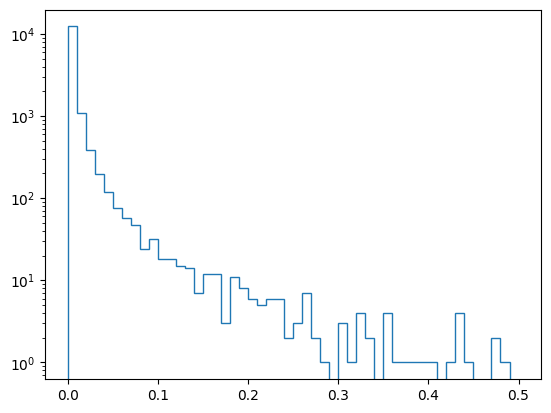

In [17]:
plt.hist(all_pt, bins=50, range=(0, 0.5), histtype="step", log=True)

plt.show()

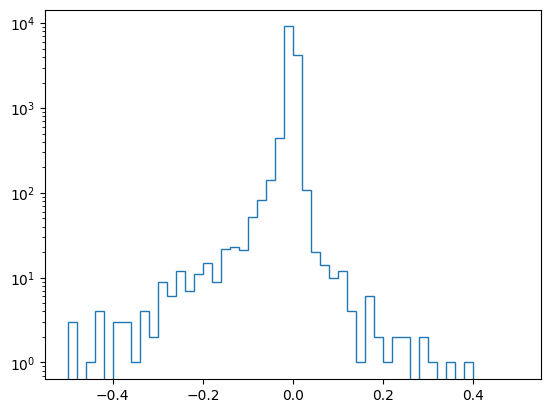

In [18]:
plt.hist(all_pz, bins=50, range=(-0.5, 0.5), histtype="step", log=True)

plt.show()